# Debugging Notebook for functions

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

Testing: 110 samples, class counts {1: 55, 7: 55}
7
Number of '7' in this set: 55, number of '1' in this set: 55


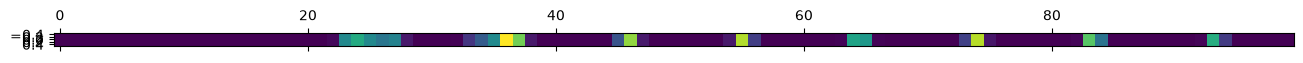

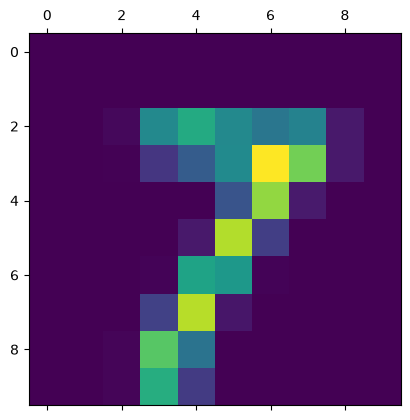

In [60]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m_side = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m_side, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1), ) #reshaping it just for plotting with plt.matshow
plt.matshow(np.real(E_X[:,0]).reshape(m_side,m_side))
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

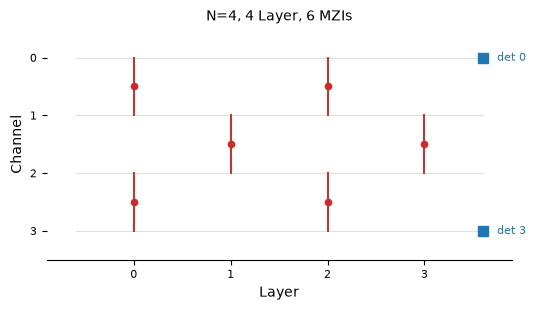

In [61]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([6.18130505, 1.4163919 ]), array([1.74028652]), array([5.04997519, 2.27296916]), array([5.39347335])]
Thetas: [array([1.00109957, 0.54845003]), array([2.94545349]), array([1.2206914 , 2.96455028]), array([2.44277639])]


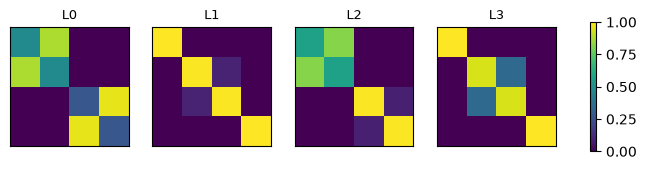

In [62]:
thetas, phis = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[ 5.63499288e-03-0.01257932j  1.56001635e-04-0.00423214j
  -9.08649650e-03-0.03116579j ...  4.63888965e-03-0.00509826j
  -7.07135253e-03-0.0069661j   7.73469208e-05-0.01465125j]
 [-4.93786122e-03-0.01520677j -4.45836718e-03-0.00692059j
   2.74545606e-02-0.01547306j ...  3.21383548e-02-0.02503923j
  -9.24894600e-03+0.0084574j  -1.46496542e-02-0.00786576j]
 [-1.04732433e-02-0.0102612j  -1.60880756e-03-0.00653972j
  -5.28057711e-02-0.01470083j ... -5.57229028e-02-0.0225899j
  -6.35803798e-03+0.01230115j -1.16639404e-02+0.00256809j]
 ...
 [ 1.34757749e-02-0.00532557j -4.14422772e-02-0.09233164j
  -1.60122321e-02+0.0213923j  ...  2.71755618e-02+0.01842195j
   3.47146365e-02-0.0047877j   1.99266826e-02+0.00815742j]
 [ 2.34745146e-02-0.05700358j -3.93982830e-02+0.04014458j
  -4.06486829e-02+0.02020897j ... -5.00932146e-03-0.00632709j
   9.90850794e-03-0.1044436j   2.29207954e-02-0.05492505j]
 [ 1.08583896e-01-0.03891802j  7.61223203e-02-0.01516443j
  -4.68709314e-02-0.00932075j ... -2.904152

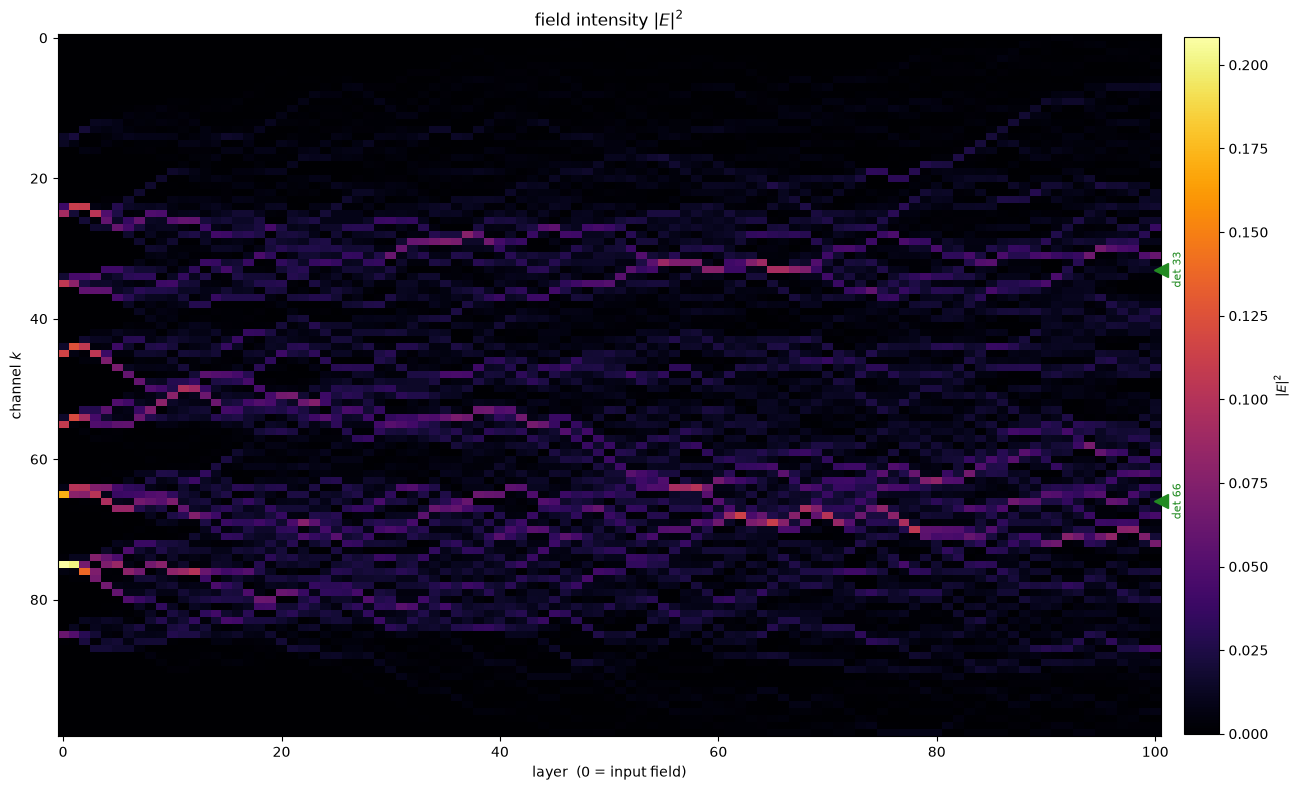

In [63]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
print(np.shape(E_hist))
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

[]

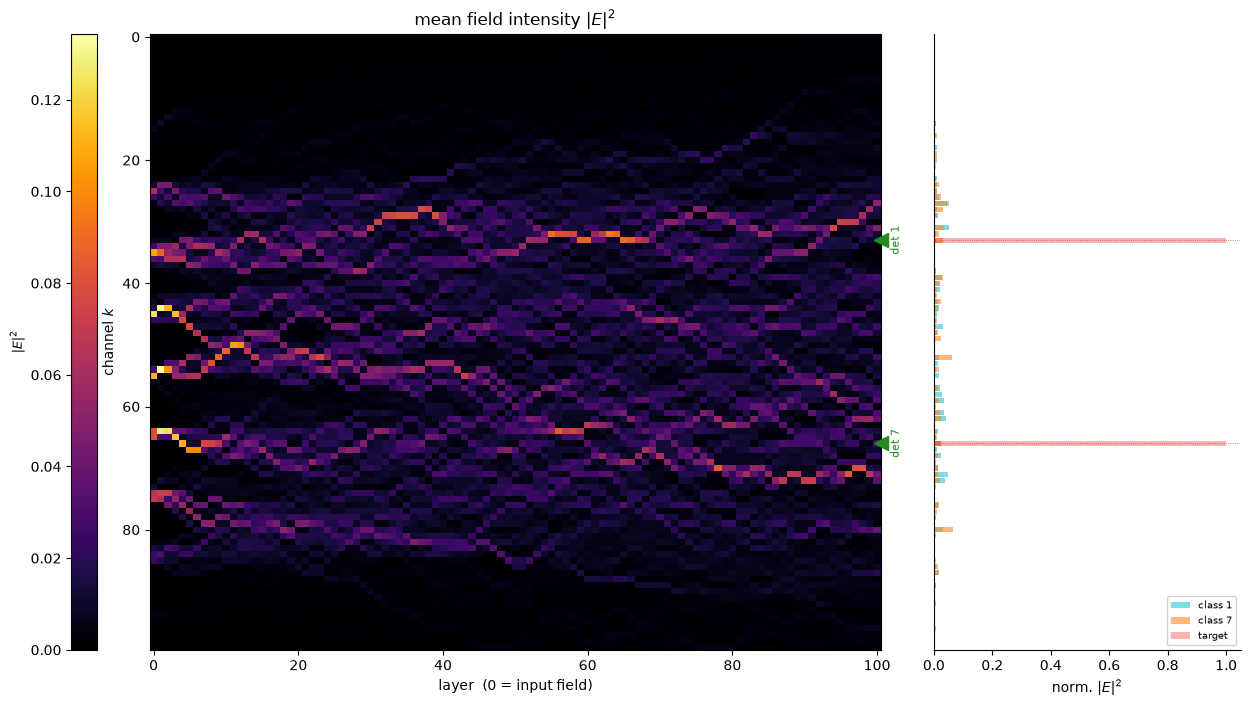

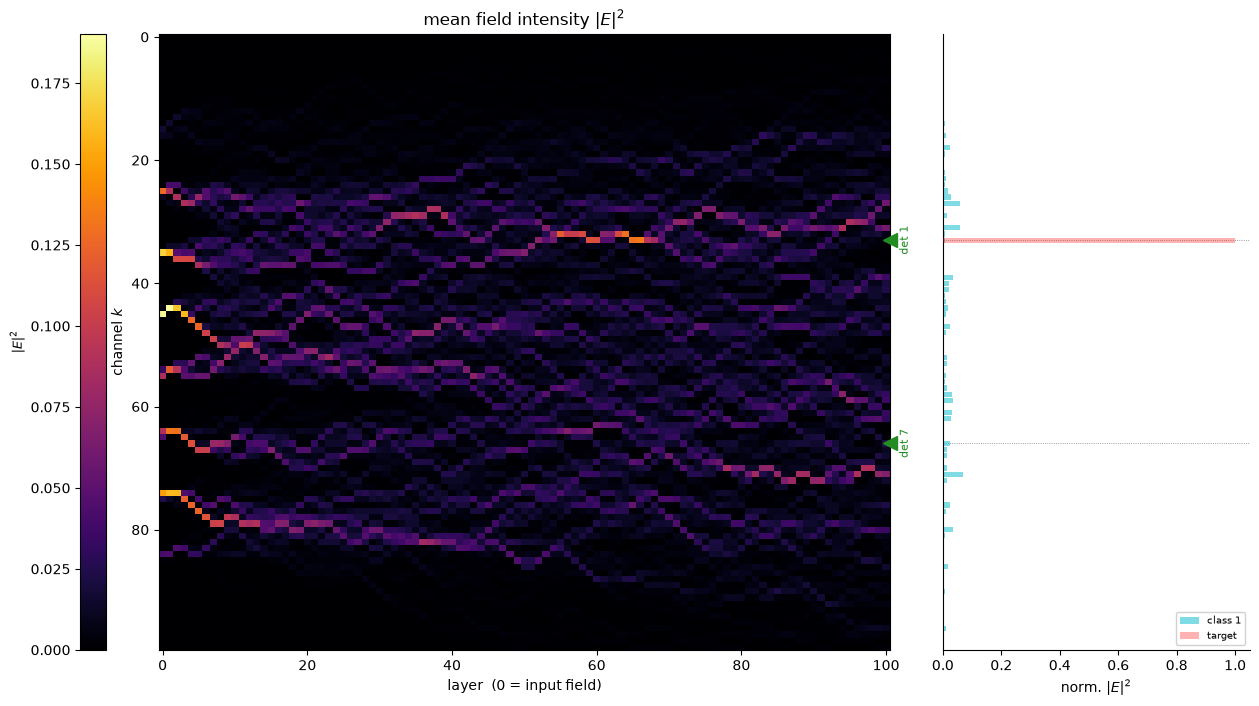

In [64]:
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,1:10])**2, det1=33, det7=66, Y=Y[1:10])
plt.plot()
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,36])**2, det1=33, det7=66, Y=Y[36])
plt.plot()

In [65]:
loss_norm=loss_function(E_hist, Y, 33, 66, kind="mse_norm" )
loss=loss_function(E_hist, Y, 33, 66, kind="mse" )


# Linear regression
## m = 10
### No normalized energy

In [66]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
print(np.shape(E_X_Train))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

Training: 12530 samples, class counts {1: 6265, 7: 6265}
(100, 12530)
Testing: 2056 samples, class counts {1: 1028, 7: 1028}
0.9854085603112841


### Normalized energy

In [67]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy_val)

Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}
0.9912451361867705


## Sweep over m
With normalized energy, balanced mode!
Takes ~4 minutes

In [68]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total

#m_sweep = np.arange(1,29,1) #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = 42 #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()

plt.plot(m_sweep, accuracies_sweep)

Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}
0.5


KeyboardInterrupt: 

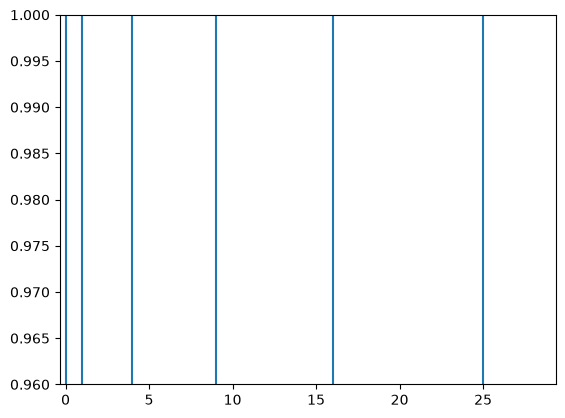

In [69]:
plt.plot(m_sweep, accuracies_sweep)
plt.ylim((0.96,1))
[plt.axvline(x=y**2) for y in range(int(np.sqrt(36)))]

[[1028    0]
 [1028    0]]


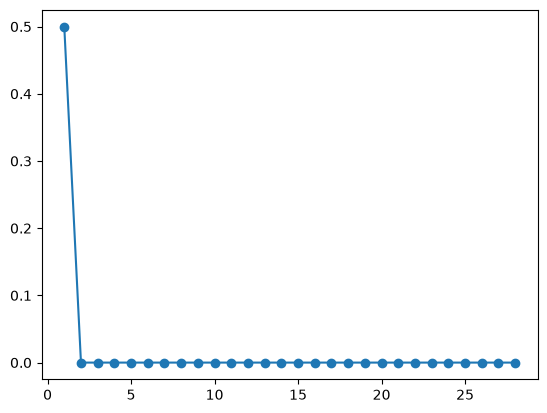

In [70]:
print(conf_matrix)
plt.plot(m_sweep, accuracies_sweep, marker="o")

In [71]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 1000 #Sets number of samples you want to get in total


m_sweep = [1] #sweeping over side length (pixel) of mnist image (1 to 28)
accuracies_sweep = np.zeros(28)

theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
for i,m in enumerate(m_sweep):
    E_X_Train, Y_Train = get_data(values, "Training", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels
    #plt.matshow(np.real(E_X_Train[:,2]).reshape((28,28)))
    E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta_enc, norm_energy, seed, balanced=True, verbose=True) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                    #Y are the referring labels

    theta, y_pred, accuracy_val, conf_matrix = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
    print(accuracy_val)
    accuracies_sweep[i]=accuracy_val.copy()


Training: 1000 samples, class counts {1: 500, 7: 500}
Testing: 1000 samples, class counts {1: 500, 7: 500}
0.5


## Plotting intensity-differences between 7 and 1

In [72]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels


Training: 12530 samples, class counts {1: 6265, 7: 6265}
Testing: 2056 samples, class counts {1: 1028, 7: 1028}


(100, 13007)


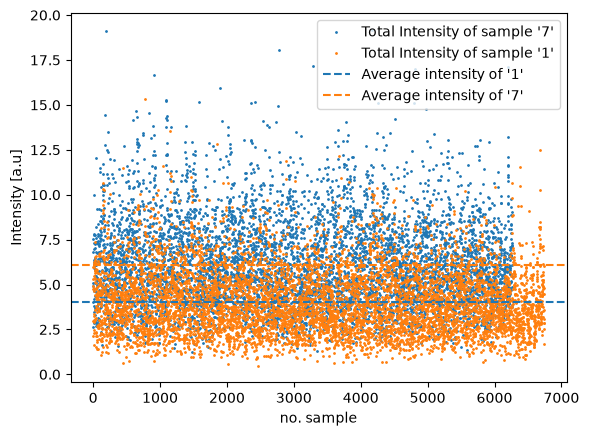

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1

sumIntensity7 = np.sum(np.abs(E_X_Train[:,mask7])**2, axis=0)
sumIntensity1 = np.sum(np.abs(E_X_Train[:,mask1])**2, axis=0)
avgIntensity7 = np.mean(sumIntensity7)
avgIntensity1 = np.mean(sumIntensity1)
plt.plot(sumIntensity7, color="tab:blue", label="Total Intensity of sample '7'", linewidth=0.0, marker="o", markersize=1)
plt.plot(sumIntensity1, color="tab:orange", label="Total Intensity of sample '1'", linewidth=0.0, marker="o", markersize=1)
plt.axhline(y=avgIntensity1, color="tab:blue", linestyle="--", label="Average intensity of '1'")
plt.axhline(y=avgIntensity7, color="tab:orange", linestyle="--", label="Average intensity of '7'")
plt.ylabel("Intensity [a.u]")
plt.xlabel("no. sample")
plt.legend()

# Trainer

In [10]:
### PREPARE TRAINING DATA

values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Training" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 1000 #Sets number of samples you want to get in total
m_side = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
balanced = True

E_X, Y = get_data(values, mode, number, m_side, theta_enc, norm_energy, seed, balanced) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices_separate(thetas, phis)   #build transfer matrices (layers) from parameters

### PREPARE TESTING DATA

values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number_t = 1000 #Sets number of samples you want to get in total
m_side = 10 #side length (pixel) of mnist image after downsampling
theta_enc = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration
balanced = True
E_X_test, Y_test = get_data(values, mode, number_t, m_side, theta_enc, norm_energy, seed, balanced) #E_X are the flattened arrays of the encoded mnist images (complex valued), 



Training: 1000 samples, class counts {1: 500, 7: 500}
Testing: 1000 samples, class counts {1: 500, 7: 500}


train 850  val 150  test 1000
val class counts: {1: 75, 7: 75}
N = 100, detectors = (33, 66)
best val_acc 1.0000 in epoch 3, 19 epochs, 90.5s
            predicted
              1      7
true   1     498      2
true   7       7    493
accuracy: 0.9910
inference: 12.34 ms/sample


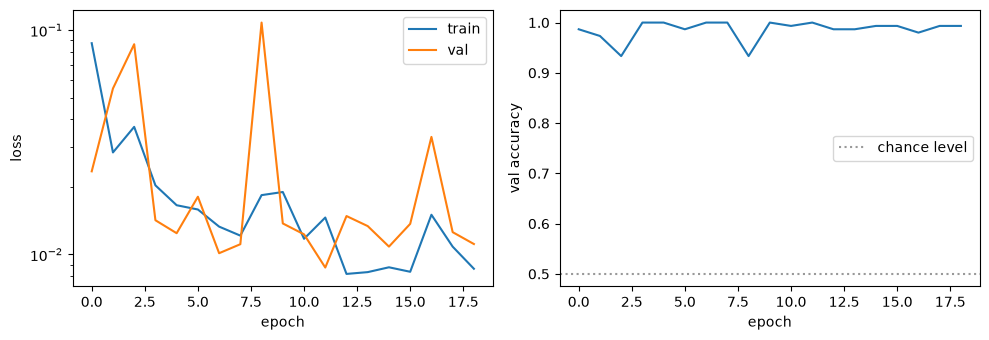

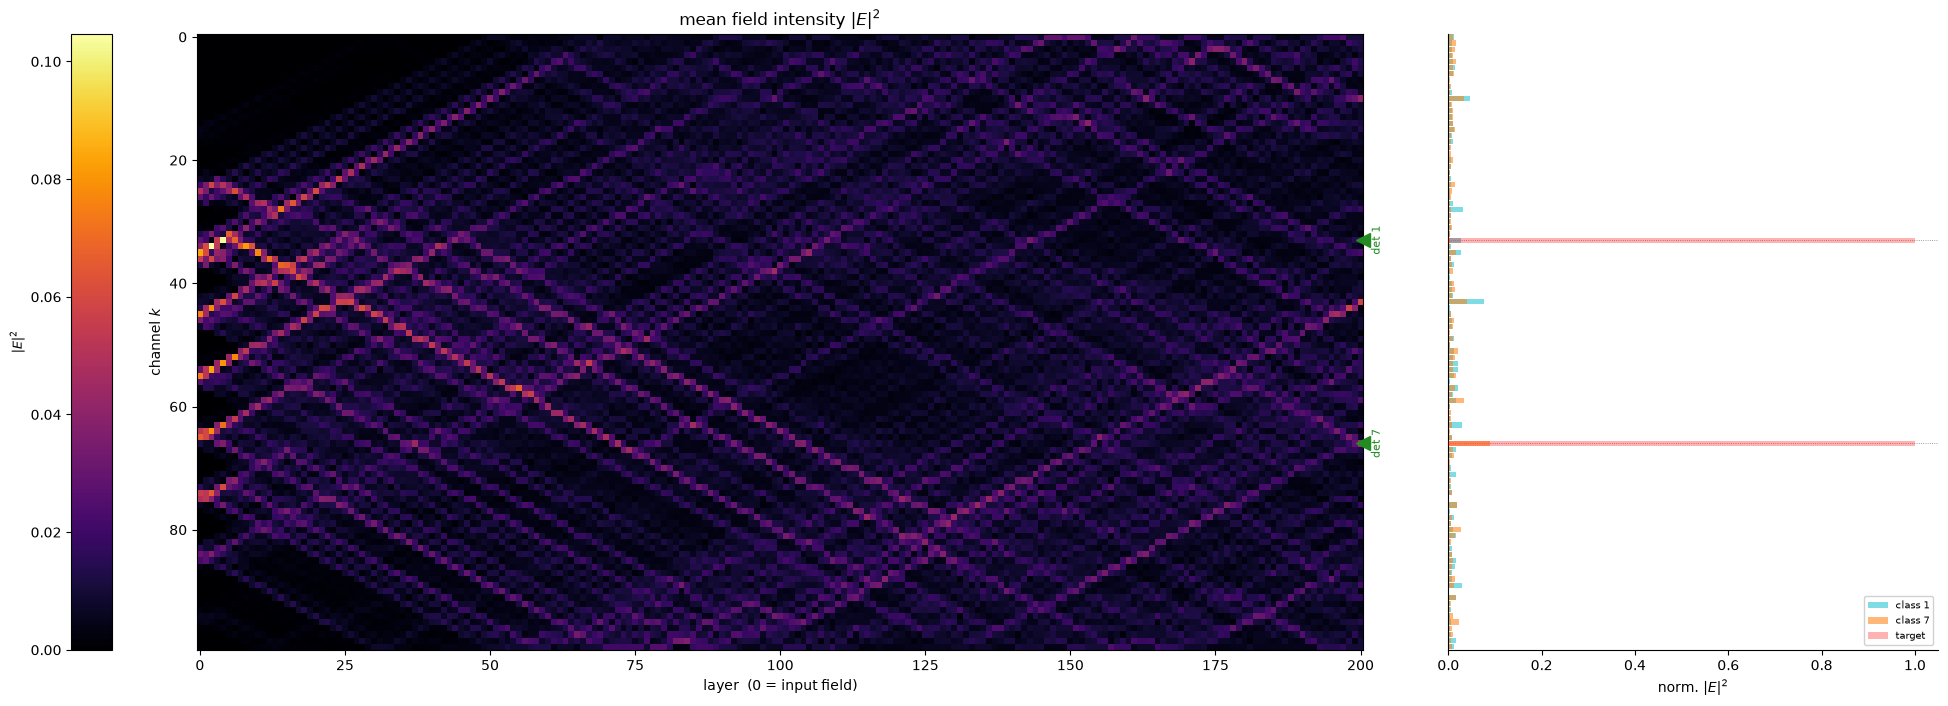

In [14]:
### TRAIN / VAL SPLIT
# Der Trainer braucht ein Validierungsset fuer Early Stopping. Es wird aus
# den TRAININGSdaten geschnitten -- das Testset bleibt komplett unberuehrt.
rs = np.random.default_rng(0)
perm = rs.permutation(E_X.shape[1])
cut = int(0.85 * len(perm))
tr_i, va_i = perm[:cut], perm[cut:]

E_train, Y_train = E_X[:, tr_i], Y[tr_i]
E_val,   Y_val   = E_X[:, va_i], Y[va_i]
print(f"train {E_train.shape[1]}  val {E_val.shape[1]}  test {E_X_test.shape[1]}")
print("val class counts:", {int(c): int((Y_val == c).sum()) for c in values})


### CONFIG + MESH
cfg = TrainConfig(m_side=m_side, theta_enc=theta_enc,
                  normalize_energy=norm_energy, n_samples=number,
                  loss_kind="mse_norm", learning_rate=0.3,
                  batch_size=64, init="haar", max_epochs=100,
                  patience=15, seed=0)
print(f"N = {cfg.N}, detectors = {cfg.detectors}")

mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))
trainer = Trainer(mesh, cfg)          # initialisiert die Gewichte selbst


### TRAINING
history = trainer.fit(E_train, Y_train, E_val, Y_val)
print(f"best val_acc {trainer.best['val_acc']:.4f} in epoch "
      f"{trainer.best['epoch']}, {len(history['val_acc'])} epochs, "
      f"{trainer.train_time:.1f}s")


### TEST -- genau EINMAL, mit den besten Gewichten
layers = mesh.layer_matrices_separate(trainer.thetas, trainer.phis,
                                      cfg.eta_bs, cfg.alpha_fiber)
E_out = forward(E_X_test, layers)
y_hat = predict(E_out, *cfg.detectors)

conf = confusion_matrix(Y_test, y_hat, classes=(1, 7))
print_confusion(conf)
print(f"inference: {trainer.inference_time(E_X_test)*1e3:.2f} ms/sample")


### PLOTS
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_yscale("log"); ax[0].legend()
ax[1].plot(history["val_acc"])
ax[1].axhline(0.5, color="0.6", ls=":", label="chance level")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val accuracy"); ax[1].legend()
fig.tight_layout()

I = np.abs(forward_history(E_X_test, layers))**2
fig, _ = plot_intensity_map_with_histogram(I, *cfg.detectors, Y_test)

Example sweep over m:

In [ ]:
for m in (4, 6, 8, 10, 14):
    cfg = TrainConfig(m_side=m, seed=0)
    mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))
    E_tr, y_tr = get_data(values, "Training", cfg.n_samples, cfg.m_side,
                          cfg.theta_enc, cfg.normalize_energy, cfg.seed)
                          #...

Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
Training: 2000 samples, class counts {1: 1000, 7: 1000}
